<a href="https://colab.research.google.com/github/sainadhsn7/2101CS77_Lab1/blob/main/datasc_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import sklearn.metrics as metrics

In [16]:
titanic = pd.read_csv('titanic.csv')
print(titanic)

titanic['Age'].fillna(np.nanmean(titanic['Age'].values), inplace = True)

print(titanic)

titanic.drop(titanic[titanic['Embarked'].isna()].index)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male   NaN      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN      NaN  
  

/tmp/ipython-input-471864710.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(np.nanmean(titanic['Age'].values), inplace = True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


    YearsExperience    Salary
0               1.1   39343.0
1               1.3   46205.0
2               1.5   37731.0
3               2.0   43525.0
4               2.2   39891.0
5               2.9   56642.0
6               3.0   60150.0
7               3.2   54445.0
8               3.2   64445.0
9               3.7   57189.0
10              3.9   63218.0
11              4.0   55794.0
12              4.0   56957.0
13              4.1   57081.0
14              4.5   61111.0
15              4.9   67938.0
16              5.1   66029.0
17              5.3   83088.0
18              5.9   81363.0
19              6.0   93940.0
20              6.8   91738.0
21              7.1   98273.0
22              7.9  101302.0
23              8.2  113812.0
24              8.7  109431.0
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0
------------------------------------------------------------
x,y train

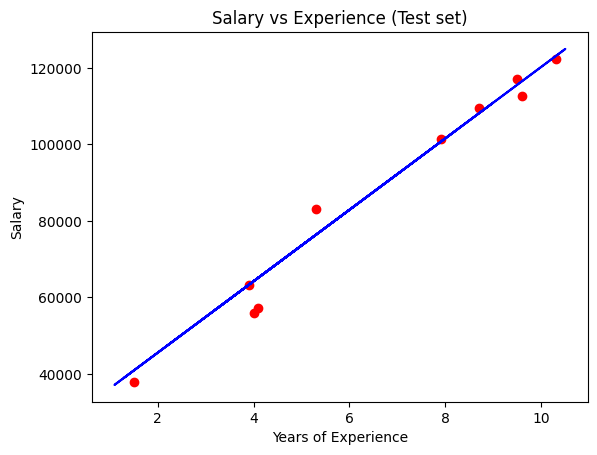

(21026037.329511296, 0.9749154407708353)

In [30]:
dataset = pd.read_csv('Dataset/Salary_Data.csv')

print(dataset, end = '\n' + '-'*60 + '\n')

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

"""## Splitting the dataset into the Training set and Test set"""

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

print("x,y train and test", X_train, y_train, X_test, y_test, sep = '\n')

"""## Training the Simple Linear Regression model on the Training set"""


linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

"""## Predicting the Test set results"""

y_pred = linear_regressor.predict(X_test)

print("y_pred", y_pred, sep = '\n')

"""## Visualising the Training set results"""

# plt.scatter(X_train, y_train, color = 'red')
# plt.plot(X_train, linear_regressor.predict(X_train), color = 'blue')
# plt.title('Salary vs Experience (Training set)')
# plt.xlabel('Years of Experience')
# plt.ylabel('Salary')
# plt.show()

"""## Visualising the Test set results"""

plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, linear_regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

linear_reg_rmse = metrics.mean_squared_error(y_test, y_pred)
linear_reg_r2 = metrics.r2_score(y_test, y_pred)

linear_reg_rmse, linear_reg_r2

In [31]:


# Importing the dataset

dataset = pd.read_csv('Dataset/50_Startups.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

print(X)

"""## Encoding categorical data"""
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

print(X)

"""## Splitting the dataset into the Training set and Test set"""


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

"""## Training the Multiple Linear Regression model on the Training set"""


milti_linear_regressor = LinearRegression()
milti_linear_regressor.fit(X_train, y_train)

"""## Predicting the Test set results"""

y_pred = milti_linear_regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

multi_linear_reg_rmse = metrics.mean_squared_error(y_test, y_pred)
multi_linear_reg_r2 = metrics.r2_score(y_test, y_pred)

multi_linear_reg_rmse, multi_linear_reg_r2

[[165349.2 136897.8 471784.1 'New York']
 [162597.7 151377.59 443898.53 'California']
 [153441.51 101145.55 407934.54 'Florida']
 [144372.41 118671.85 383199.62 'New York']
 [142107.34 91391.77 366168.42 'Florida']
 [131876.9 99814.71 362861.36 'New York']
 [134615.46 147198.87 127716.82 'California']
 [130298.13 145530.06 323876.68 'Florida']
 [120542.52 148718.95 311613.29 'New York']
 [123334.88 108679.17 304981.62 'California']
 [101913.08 110594.11 229160.95 'Florida']
 [100671.96 91790.61 249744.55 'California']
 [93863.75 127320.38 249839.44 'Florida']
 [91992.39 135495.07 252664.93 'California']
 [119943.24 156547.42 256512.92 'Florida']
 [114523.61 122616.84 261776.23 'New York']
 [78013.11 121597.55 264346.06 'California']
 [94657.16 145077.58 282574.31 'New York']
 [91749.16 114175.79 294919.57 'Florida']
 [86419.7 153514.11 0.0 'New York']
 [76253.86 113867.3 298664.47 'California']
 [78389.47 153773.43 299737.29 'New York']
 [73994.56 122782.75 303319.26 'Florida']
 [67532

(83502864.03256194, 0.9347068473282546)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]] [  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


/tmp/ipython-input-1048471023.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


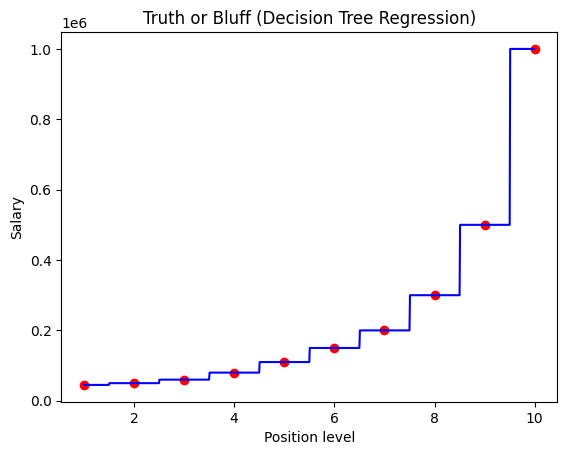

(83502864.03256194, 0.9347068473282546)

In [32]:
dataset = pd.read_csv('Dataset/Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
Y = dataset.iloc[:, -1].values

print(X, Y)
# ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
# X = np.array(ct.fit_transform(X))
# print(X)

"""## Training the Decision Tree Regression model on the whole dataset"""

from sklearn.tree import DecisionTreeRegressor
decision_tree_regressor = DecisionTreeRegressor(random_state = 0)
decision_tree_regressor.fit(X, Y)

"""## Predicting a new result"""

# print(decision_tree_regressor.predict([[6.5]]))

"""## Visualising the Decision Tree Regression results (higher resolution)"""

X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, Y, color = 'red')
plt.plot(X_grid, decision_tree_regressor.predict(X_grid), color = 'blue')
plt.title('Truth or Bluff (Decision Tree Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

decision_tree_rmse = metrics.mean_squared_error(y_test, y_pred)
decision_tree_r2 = metrics.r2_score(y_test, y_pred)

decision_tree_rmse, decision_tree_r2

/tmp/ipython-input-1336388191.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


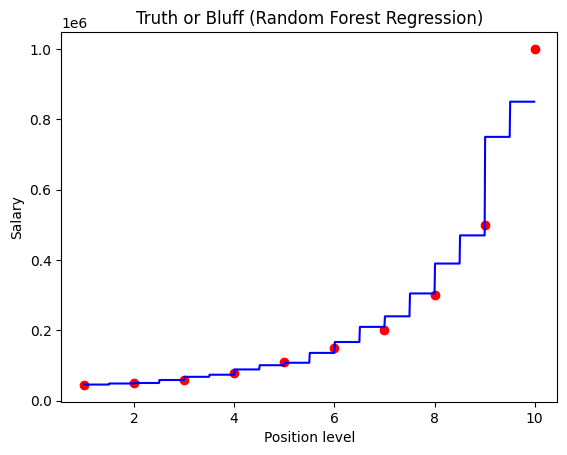

(83502864.03256194, 0.9347068473282546)

In [33]:
dataset = pd.read_csv('Dataset/Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

"""## Training the Random Forest Regression model on the whole dataset"""

from sklearn.ensemble import RandomForestRegressor
random_forest_regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
random_forest_regressor.fit(X, y)

"""## Predicting a new result"""

random_forest_regressor.predict([[6.5]])

"""## Visualising the Random Forest Regression results (higher resolution)"""

X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, random_forest_regressor.predict(X_grid), color = 'blue')
plt.title('Truth or Bluff (Random Forest Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

random_forest_reg_rmse = metrics.mean_squared_error(y_test, y_pred)
random_forest_reg_r2 = metrics.r2_score(y_test, y_pred)

random_forest_reg_rmse, random_forest_reg_r2

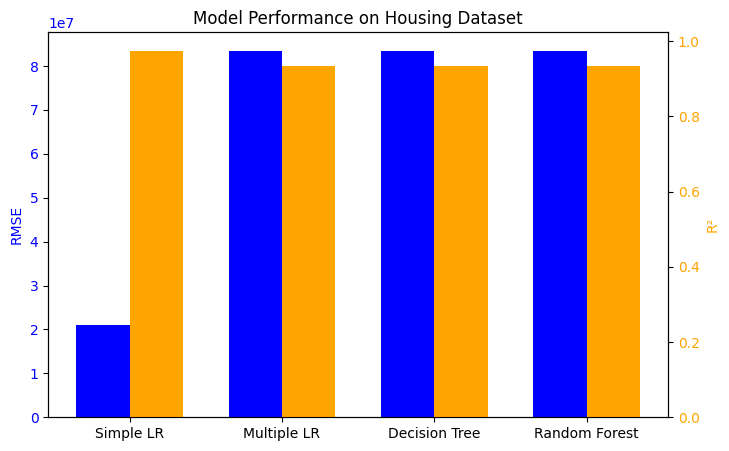

In [38]:

# Example results (replace with your values)
models = ["Simple LR", "Multiple LR", "Decision Tree", "Random Forest"]
rmse = [linear_reg_rmse, multi_linear_reg_rmse, decision_tree_rmse, random_forest_reg_rmse]
r2 = [linear_reg_r2, multi_linear_reg_r2, decision_tree_r2, random_forest_reg_r2]

x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8,5))

# RMSE (left axis)
ax1.bar(x - width/2, rmse, width, label="RMSE", color="blue")
ax1.set_ylabel("RMSE", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# R² (right axis)
ax2 = ax1.twinx()
ax2.bar(x + width/2, r2, width, label="R²", color="orange")
ax2.set_ylabel("R²", color="orange")
ax2.tick_params(axis='y', labelcolor="orange")

ax1.set_xticks(x)
ax1.set_xticklabels(models)
plt.title("Model Performance on Housing Dataset")
plt.show()

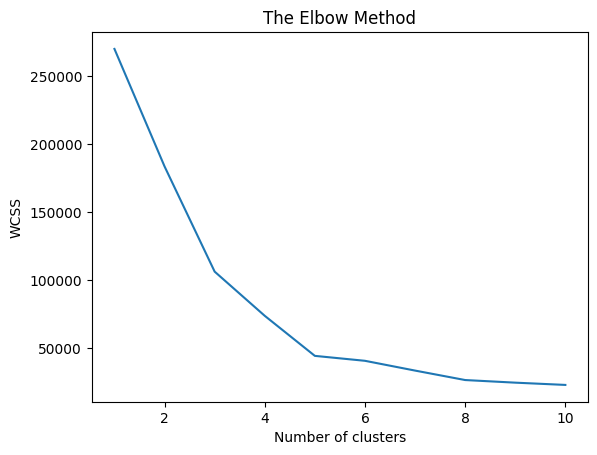

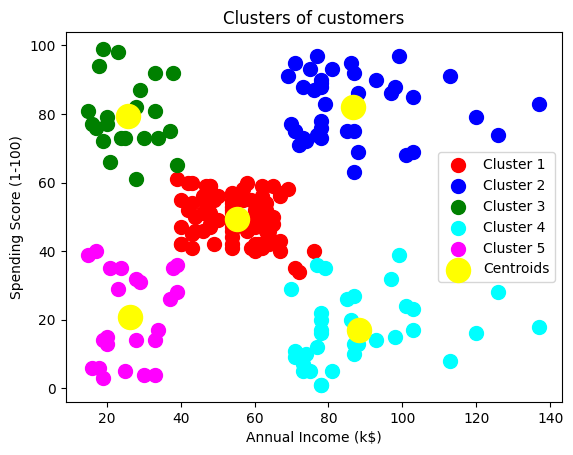

In [39]:


# Importing the dataset

dataset = pd.read_csv('Dataset/Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values
# Using the elbow method to find the optimal number of clusters

from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Training the K-Means model on the dataset

kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

# Visualising the clusters

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

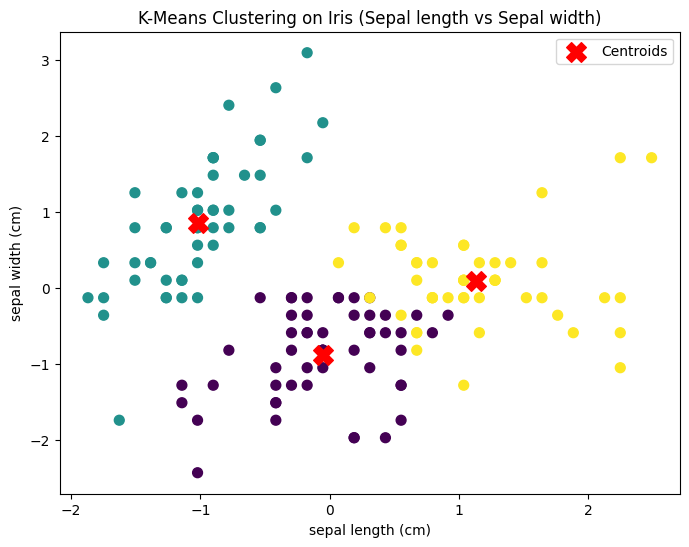

Confusion Matrix:
 [[50  0  0]
 [ 0 39 11]
 [ 0 14 36]]
Accuracy: 0.8333333333333334


In [44]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# 1. Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 2. Preprocessing: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply K-Means (k=3 since there are 3 Iris species)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# 4. Visualization (first two features: sepal length vs sepal width)
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title("K-Means Clustering on Iris (Sepal length vs Sepal width)")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.show()

# 5. Evaluation: Confusion matrix & accuracy
# Note: Cluster labels are arbitrary → may need relabeling for accuracy
from scipy.stats import mode

# Map cluster labels to true labels
labels = np.zeros_like(y_kmeans)
for i in range(3):
    mask = (y_kmeans == i)
    labels[mask] = mode(y[mask], keepdims=True)[0]

cm = metrics.confusion_matrix(y, labels)
acc = metrics.accuracy_score(y, labels)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)

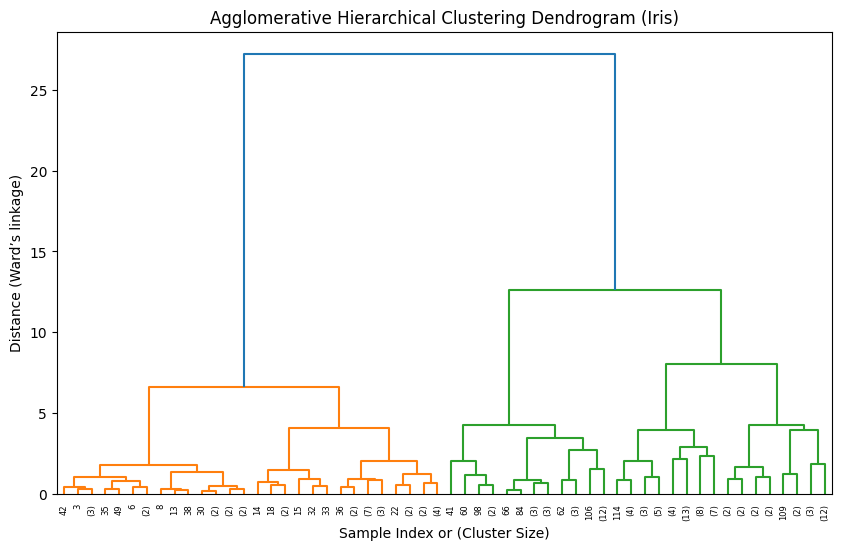

Confusion Matrix:
 [[49  1  0]
 [ 0 27 23]
 [ 0  2 48]]
Accuracy: 0.8266666666666667


In [45]:

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Load Iris dataset
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply Agglomerative Clustering (n_clusters=3)
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_agg = agg_clustering.fit_predict(X_scaled)

# 4. Dendrogram Visualization
plt.figure(figsize=(10, 6))
Z = linkage(X_scaled, method='ward')  # linkage matrix
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Agglomerative Hierarchical Clustering Dendrogram (Iris)")
plt.xlabel("Sample Index or (Cluster Size)")
plt.ylabel("Distance (Ward’s linkage)")
plt.show()

# 5. Interpretation
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.stats import mode

# Align predicted labels with true labels
labels = np.zeros_like(y_agg)
for i in range(3):
    mask = (y_agg == i)
    labels[mask] = mode(y[mask], keepdims=True)[0]

cm = confusion_matrix(y, labels)
acc = accuracy_score(y, labels)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)